# Microsoft Foundry Local 
## Deploying Custom Models with Microsoft Olive and Foundry Local

<img src="https://github.com/retkowsky/foundry-local/blob/main/foundrylocal.jpg?raw=true">
          
## What This Notebook Does

This notebook demonstrates a **complete pipeline** for taking a `Hugging Face` model, optimizing it for
local inference, and serving it through Microsoft Foundry Local — all without requiring cloud resources
or GPU hardware.

### Key Technologies

| Component | Role |
|---|---|
| **[Microsoft Olive](https://github.com/microsoft/Olive)** | Model optimization toolkit — converts PyTorch models to ONNX format with graph optimizations and quantization (INT4/INT8/FP16) |
| **[Microsoft Foundry Local](https://github.com/microsoft/Foundry-Local)** | Local model serving runtime — hosts ONNX models behind an OpenAI-compatible API endpoint |
| **[ONNX Runtime](https://onnxruntime.ai/)** | High-performance inference engine that powers Foundry Local's model execution |
| **[Hugging Face Hub](https://huggingface.co/)** | Source repository for the pre-trained model weights |

### What You Will Learn

1. How to **download** a Hugging Face model locally for offline use
2. How to **optimize** a model with Olive's `auto-opt` pipeline (ONNX conversion + INT4 quantization)
3. How to **measure** the size reduction achieved by quantization
4. How to **configure** a chat template for Foundry Local compatibility
5. How to **register** and **serve** a custom model through Foundry Local
6. How to **query** the model using the OpenAI Python client

### Prerequisites

- **Python 3.12** (Foundry Local SDK requirement)
- **Microsoft Foundry Local** installed and available on PATH
- **Olive** installed with the `auto-opt` extras: `pip install olive-ai[auto-opt]`
- ~4 GB free disk space (for the source model + optimized output)

> **Note:** This notebook targets **CPU inference** with INT4 quantization. For GPU setups,
> adjust the `DEVICE` and `EP` (Execution Provider) configuration variables below.

### Deployment Options for Your SLM Application

| Option | Approach | Best For |
|--------|----------|----------|
| **vLLM Container** | Industry standard for cloud deployments — containerized, scalable, handles high concurrency | Cloud / Production (Azure VMs, Kubernetes) |
| **Ollama Container** | Simpler than vLLM with Docker support for easy sharing and deployment | Hybrid / Sharing |
| **Foundry Local + Olive** | Microsoft's edge-first approach — optimize with Olive, serve with Foundry Local or a custom server | Edge / On-Premise, offline, privacy-focused |

> In this example, we focus on the **Foundry Local** path, using **Qwen 2.5-1.5B-Instruct** — small enough to optimize quickly and demonstrate the full workflow. Think of it as a stand-in for a model you've fine-tuned on your own data.


### Documentation
- https://www.foundrylocal.ai/models
- https://learn.microsoft.com/en-us/azure/ai-foundry/foundry-local/get-started?view=foundry-classic

## Author

| Field | Details |
| --- | --- |
| Name | Serge Retkowsky |
| Email | serge.retkowsky@microsoft.com |
| LinkedIn | https://www.linkedin.com/in/serger/ |
| Medium publications | https://medium.com/@sergems18/ |

In [1]:
# %pip install olive-ai[auto-opt]
# %pip install "transformers>=4.40,<5.0"   # Olive requires transformers 4.x (NOT 5.x)
# %pip install onnxruntime-genai
# %pip install onnxruntime
# %pip install huggingface_hub
# %pip install openai
# %pip install foundry-local

In [2]:
import datetime
import GPUtil
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import openai
import os
import pandas as pd
import platform
import psutil
import requests
import shutil
import subprocess
import sys
import time

from datetime import datetime, timezone
from huggingface_hub import snapshot_download, login, whoami
from foundry_local import FoundryLocalManager
from openai import OpenAI
from pathlib import Path
from transformers import AutoTokenizer

In [3]:
print(f"Python version: {sys.version}")

Python version: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]


In [4]:
print(f"Today is {datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 25-Feb-2026 16:22:32


In [5]:
print(f"💻 OS: {platform.system()} {platform.release()}")
print(f"- CPU: {platform.processor()}")
print(f"- CPU cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count()} logical")

ram = psutil.virtual_memory()
print(f"- RAM total:     {ram.total / (1024**3):.1f} GB")
print(f"- RAM available: {ram.available / (1024**3):.1f} GB")
print(f"- RAM used:      {ram.percent}%")

for part in psutil.disk_partitions():
    try:
        usage = psutil.disk_usage(part.mountpoint)
        print(f"\n💾 Disk [{part.device}] mounted on {part.mountpoint}")
        print(f"- Total: {usage.total / (1024**3):.1f} GB")
        print(f"- Used:  {usage.used / (1024**3):.1f} GB ({usage.percent}%)")
        print(f"- Free:  {usage.free / (1024**3):.1f} GB")
    except PermissionError:
        pass

gpus = GPUtil.getGPUs()

if not gpus:
    print("No GPU detected.")
else:
    for i, gpu in enumerate(gpus):
        print(f"\n🎮 GPU {i} — {gpu.name}")
        print(f"- VRAM Total : {gpu.memoryTotal:,.0f} MB")
        print(
            f"- VRAM Used  : {gpu.memoryUsed:,.0f} MB ({gpu.memoryUtil * 100:.0f}%)"
        )
        print(f"- VRAM Free  : {gpu.memoryFree:,.0f} MB")
        print(f"- GPU Load   : {gpu.load * 100:.0f}%")
        print(f"- Temperature: {gpu.temperature} °C")

💻 OS: Windows 11
- CPU: Intel64 Family 6 Model 141 Stepping 1, GenuineIntel
- CPU cores: 8 physical, 16 logical
- RAM total:     63.7 GB
- RAM available: 30.9 GB
- RAM used:      51.5%

💾 Disk [C:\] mounted on C:\
- Total: 951.6 GB
- Used:  878.5 GB (92.3%)
- Free:  73.2 GB

🎮 GPU 0 — NVIDIA T1200 Laptop GPU
- VRAM Total : 4,096 MB
- VRAM Used  : 3,733 MB (91%)
- VRAM Free  : 203 MB
- GPU Load   : 35%
- Temperature: 69.0 °C


## Configuration

| Precision | Size Reduction | Quality | Best For |
|-----------|---------------|---------|----------|
| **FP32** | Baseline | Best | Development, debugging |
| **FP16** | 50% smaller | Excellent | GPU inference with plenty of VRAM |
| **INT8** | 75% smaller | Very Good | **Balanced production** |
| **INT4** | 87.5% smaller | Good | Edge devices, resource-constrained |

In [6]:
HF_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"  # Source model on Hugging Face
MODEL_NAME = "my-qwen-model"                # Local friendly name

In [7]:
PRECISION = "int4"
DEVICE = "cpu"
EP = "CPUExecutionProvider"                 # ONNX Runtime execution provider

In [8]:
BASE_DIR = Path(r"C:\models")               # Dir to store the models
LOCAL_MODEL_PATH = BASE_DIR / "hf"          # Downloaded HF weights
OUTPUT_DIR = BASE_DIR / "onnx"              # Olive optimized output

OLIVE_CMD = [sys.executable, "-m", "olive"]

In [9]:
print(BASE_DIR)

C:\models


In [10]:
print(LOCAL_MODEL_PATH)

C:\models\hf


In [11]:
print(OUTPUT_DIR)

C:\models\onnx


## Verify Olive Installation

Before proceeding, let's confirm that the Olive CLI is accessible from the current
Python environment.


In [12]:
# Check Olive CLI is available via python -m olive
result = subprocess.run(OLIVE_CMD + ["auto-opt", "--help"],
                        capture_output=True,
                        text=True)

if result.returncode == 0:
    # Also show the Olive executable path for reference
    olive_path = Path(sys.executable).parent / "Scripts" / "olive.exe"

    if olive_path.exists():
        print(f"Olive CLI is available => {olive_path}")
    else:
        print("Olive CLI is available (via python -m olive)")
else:
    print("Olive CLI not found. Install with: pip install olive-ai[auto-opt]")
    print(result.stderr[:500])

Olive CLI is available => C:\Users\seretkow\AppData\Local\anaconda3\envs\foundry\Scripts\olive.exe


## (Optional) Authenticate with Hugging Face

Required for **gated models** (Llama, Mistral, etc.). Public models like Qwen do not
need authentication, but logging in avoids occasional rate-limiting on the Hub.

Set the `HF_TOKEN` environment variable or paste your token below.


In [13]:
HF_TOKEN = os.getenv("HF_TOKEN", "")

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    user = whoami()
    print(f"Logged in as: {user['name']}")
else:
    print("No 'HF_TOKEN' found: Proceeding without authentication\
    (fine for public models)")

No 'HF_TOKEN' found: Proceeding without authentication    (fine for public models)


## Download the Model Locally

We download the full model snapshot from Hugging Face before running Olive. This avoids
Olive triggering internal authentication on public models and gives us a local cache
for repeated experiments.

Non-PyTorch weight formats (`.msgpack`, `.h5`, Flax) are skipped to save bandwidth.


In [14]:
manager = FoundryLocalManager()
manager.start_service()

print(f"Service running : {manager.is_service_running()}")
print(f"Service URI     : {manager.service_uri}")
print(f"Endpoint (v1)   : {manager.endpoint}")
print(f"Cache location  : {manager.get_cache_location()}")

Service running : True
Service URI     : http://127.0.0.1:55311
Endpoint (v1)   : http://127.0.0.1:55311/v1
Cache location  : C:\models


In [15]:
if LOCAL_MODEL_PATH.exists() and any(LOCAL_MODEL_PATH.iterdir()):
    print(f"Model already downloaded at: {LOCAL_MODEL_PATH}")

else:
    print(f"Downloading {HF_MODEL_ID} from Hugging Face... Please wait.")
    t0 = time.time()

    snapshot_download(
        repo_id=HF_MODEL_ID,
        local_dir=str(LOCAL_MODEL_PATH),
        ignore_patterns=["*.msgpack", "*.h5", "flax_model*"],
    )

    elapsed = time.time() - t0
    print(f"✅ Downloaded in {elapsed:.1f} secs in {LOCAL_MODEL_PATH}")

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

✅ Downloaded in 46.7 secs in C:\models\hf


### Inspect Downloaded Files

Quick inventory of the downloaded model artefacts and their sizes.


In [16]:
os.listdir(BASE_DIR)

['hf', 'Microsoft']

In [17]:
# Get all hf cached models
cache_dir = os.path.join(manager.get_cache_location(), "hf")
cached = os.listdir(cache_dir)

for c in cached:
    path = os.path.join(cache_dir, c)
    stat = os.stat(path)
    size_mb = stat.st_size / (1024 * 1024)
    modified = datetime.fromtimestamp(stat.st_mtime).strftime("%Y-%m-%d %H:%M")
    print(f"{c:30s} {size_mb:8.3f} MB  {modified}")

.cache                            0.000 MB  2026-02-25 16:23
.gitattributes                    0.001 MB  2026-02-25 16:23
config.json                       0.001 MB  2026-02-25 16:23
generation_config.json            0.000 MB  2026-02-25 16:23
LICENSE                           0.011 MB  2026-02-25 16:23
merges.txt                        1.594 MB  2026-02-25 16:23
model.safetensors              2944.438 MB  2026-02-25 16:24
README.md                         0.005 MB  2026-02-25 16:23
tokenizer.json                    6.706 MB  2026-02-25 16:23
tokenizer_config.json             0.007 MB  2026-02-25 16:23
vocab.json                        2.648 MB  2026-02-25 16:23


## Optimise with Microsoft Olive

Olive's `auto-opt` command handles the full optimisation pipeline in a single step:

1. **ONNX Conversion** — Exports the PyTorch model to ONNX format using Model Builder
2. **Graph Optimisation** — Applies operator fusion, constant folding, and dead-code elimination
3. **Quantisation** — Compresses weights to the target precision (INT4 by default), reducing model
   size by ~60–75% with minimal quality loss

In [18]:
onnx_files = list(OUTPUT_DIR.rglob("*.onnx"))

if onnx_files:
    print(f"✅ ONNX model already exists ({len(onnx_files)} file(s)):")
    for f in onnx_files:
        size_mb = f.stat().st_size / 1e6
        print(f"   {f.name}  ({size_mb:,.1f} MB)")
else:
    print("🔄 Starting Olive optimisation pipeline...")
    print(f"Source    : {LOCAL_MODEL_PATH}")
    print(f"Target    : {OUTPUT_DIR}")
    print(f"Precision : {PRECISION} | Device: {DEVICE}")
    print(f"Provider  : {EP}")
    print("\nThis may take some time depending on hardware.\n")

    cmd = OLIVE_CMD + [
        "auto-opt",
        "--model_name_or_path",
        str(LOCAL_MODEL_PATH),
        "--device",
        DEVICE,
        "--provider",
        EP,
        "--use_model_builder",
        "--precision",
        PRECISION,
        "--output_path",
        str(OUTPUT_DIR),
        "--log_level",
        "1",
        "--trust_remote_code",
    ]

    start = time.time()
    result = subprocess.run(cmd, capture_output=False, text=True)
    elapsed = time.time() - start

    if result.returncode == 0:
        print(f"\n✅ Optimisation complete in {elapsed / 60:.1f} min")
    else:
        print(f"\n❌ Olive optimisation failed (exit code {result.returncode})")
        raise RuntimeError(
            "Olive auto-opt failed. Check the output above for details.")

🔄 Starting Olive optimisation pipeline...
Source    : C:\models\hf
Target    : C:\models\onnx
Precision : int4 | Device: cpu
Provider  : CPUExecutionProvider

This may take some time depending on hardware.


✅ Optimisation complete in 1.0 min


### Inspect Optimised Artefacts


In [19]:
onnx_all = [f for f in OUTPUT_DIR.rglob("*") if f.is_file()]

df_onnx = pd.DataFrame([{
    "name": f.name,
    "size_mb": round(f.stat().st_size / 1e6, 2),
} for f in sorted(onnx_all)])

total_onnx_mb = df_onnx["size_mb"].sum()
print(f"Total = {len(df_onnx)} files, {total_onnx_mb:,.0f} Mgb")

Total = 9 files, 1,931 Mgb


In [20]:
df_onnx.sort_values("size_mb", ascending=False)

,name,size_mb
5,model.onnx.data,1919.81
7,tokenizer.json,11.42
4,model.onnx,0.22
0,chat_template.jinja,0.00
1,config.json,0.00
3,generation_config.json,0.00
2,genai_config.json,0.00
6,model_config.json,0.00
8,tokenizer_config.json,0.00


### Size Comparison: Original vs Optimised

A visual comparison of model sizes before and after `Olive` optimisation.


In [21]:
def get_dir_size_mb(path: Path) -> float:
    """Return total size of all files under 'path' in MB."""

    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / 1e6

Original model size =  3,099.0 MB
Optimised ONNX size =  1,931.5 MB
Size reduction =    37.7 %


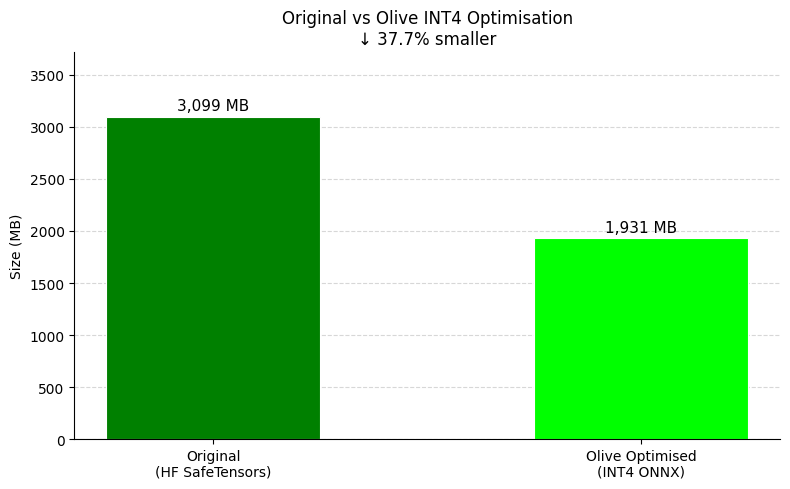

In [22]:
original_mb = get_dir_size_mb(LOCAL_MODEL_PATH)
optimized_mb = get_dir_size_mb(OUTPUT_DIR)
reduction_pct = (1 - optimized_mb / original_mb) * 100

print(f"Original model size = {original_mb:>8,.1f} MB")
print(f"Optimised ONNX size = {optimized_mb:>8,.1f} MB")
print(f"Size reduction = {reduction_pct:>7.1f} %")

fig, ax = plt.subplots(figsize=(8, 5))

labels = [
    "Original\n(HF SafeTensors)",
    f"Olive Optimised\n({PRECISION.upper()} ONNX)"
]
values = [original_mb, optimized_mb]
colors = ["green", "lime"]

bars = ax.bar(labels,
              values,
              color=colors,
              width=0.5,
              edgecolor="white",
              linewidth=0.8)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.02,
        f"{val:,.0f} MB",
        ha="center",
        fontsize=11,
    )

ax.set_ylabel("Size (MB)")
ax.set_title(
    f"Original vs Olive {PRECISION.upper()} Optimisation\n"
    f"↓ {reduction_pct:.1f}% smaller",
    fontsize=12,
)
ax.set_ylim(0, max(values) * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()

plt.show()

## Create the Foundry Local Chat Template

Foundry Local requires an `inference_model.json` file in the model directory. This file
defines the **prompt template** so the runtime knows how to format chat messages
(system / user / assistant turns) for the model's expected input format.

We extract the template programmatically from the model's tokenizer to avoid manual errors.


In [23]:
# Load the tokenizer from the downloaded HF model
tokenizer = AutoTokenizer.from_pretrained(str(LOCAL_MODEL_PATH),
                                          trust_remote_code=True)

# Build a sample conversation to extract the template structure
sample_messages = [
    {
        "role": "system",
        "content": "{system_prompt}"
    },
    {
        "role": "user",
        "content": "{Content}"
    },
]

chat_template_str = tokenizer.apply_chat_template(
    sample_messages,
    tokenize=False,
    add_generation_prompt=True,
)
print("Extracted chat template:")
print("-" * 50)
print(chat_template_str)
print("-" * 50)

# Determine the actual ONNX model directory (Olive may create a subfolder)
onnx_model_dirs = [d for d in OUTPUT_DIR.iterdir() if d.is_dir()]
model_dir = onnx_model_dirs[0] if onnx_model_dirs else OUTPUT_DIR

# Write inference_model.json
inference_config = {
    "model": MODEL_NAME,
    "prompt_template": {
        "system": "",
        "user": chat_template_str,
    }
}

config_path = model_dir / "inference_model.json"
config_path.write_text(json.dumps(inference_config, indent=2))
print(f"✅ Written: {config_path}")

Extracted chat template:
--------------------------------------------------
<|im_start|>system
{system_prompt}<|im_end|>
<|im_start|>user
{Content}<|im_end|>
<|im_start|>assistant

--------------------------------------------------
✅ Written: C:\models\onnx\inference_model.json


## Register & Serve the Model with Foundry Local

With the optimised ONNX model and chat template ready, we can now:

1. **Start** the Foundry Local service
2. **Point the cache** to our models directory so Foundry discovers our custom model
3. **Load** the model via the REST API


In [27]:
manager = FoundryLocalManager()
manager.start_service()

print(f"Service running : {manager.is_service_running()}")
print(f"Service URI     : {manager.service_uri}")
print(f"Endpoint (v1)   : {manager.endpoint}")
print(f"Cache location  : {manager.get_cache_location()}")

Service running : True
Service URI     : http://127.0.0.1:55311
Endpoint (v1)   : http://127.0.0.1:55311/v1
Cache location  : C:\models


### Prepare the Model Directory

Foundry Local expects ONNX files directly inside a model folder in its cache. We copy the
Olive output to a clean directory name that Foundry can discover.

> **Adapt the paths below** to match your local setup if needed.


In [29]:
# Name as it will appear in Foundry
FOUNDRY_MODEL_NAME = MODEL_NAME
MODELS_ROOT = Path(r"C:\models")

src = OUTPUT_DIR  # Olive output
dst = MODELS_ROOT / FOUNDRY_MODEL_NAME  # Target in Foundry cache

if dst.exists() and any(dst.iterdir()):
    print(f"✅ Model directory already exists: {dst}")
else:
    shutil.copytree(src, dst, dirs_exist_ok=True)
    print(f"✅ Copied ONNX artefacts => {dst}")

# Verify contents
print(f"\nFiles in {dst.name}/:")
for f in sorted(dst.iterdir()):
    print(f"- {f.name}")

✅ Model directory already exists: C:\models\my-qwen-model

Files in my-qwen-model/:
- chat_template.jinja
- config.json
- genai_config.json
- generation_config.json
- inference_model.json
- model.onnx
- model.onnx.data
- model_config.json
- tokenizer.json
- tokenizer_config.json


## Run Local Inference

The model is now served behind an **OpenAI-compatible API**. We can use the standard
`openai` Python client — just point it at our local endpoint. No API key is required.


In [42]:
client = OpenAI(
    base_url=f"{manager.endpoint}",
    api_key="not-needed",
)

In [43]:
prompt = "What is the golden ratio? Explain in 2-3 sentences."

In [44]:
start = time.time()

stream = client.chat.completions.create(
    model=FOUNDRY_MODEL_NAME,
    messages=[{
        "role": "user",
        "content": prompt
    }],
    stream=True,
    stream_options={"include_usage": True},  # ← enables usage in last chunk
)

full_response = []
for chunk in stream:
    # Debug: inspect the full chunk object
    #print(chunk.model_dump_json(indent=2))

    if chunk.choices:
        delta = chunk.choices[0].delta
        token = delta.content
        if token:
            print(token, end="", flush=True)
            full_response.append(token)

        # Finish reason (appears in the last content chunk)
        if chunk.choices[0].finish_reason:
            print(f"\n\n⏹️  Finish reason: {chunk.choices[0].finish_reason}")

    # Model info (available on every chunk)
    if chunk.model:
        model_used = chunk.model

    # Usage stats (only in the final chunk when stream_options is set)
    if chunk.usage:
        print(f"📊 Prompt tokens:     {chunk.usage.prompt_tokens}")
        print(f"📊 Completion tokens: {chunk.usage.completion_tokens}")
        print(f"📊 Total tokens:      {chunk.usage.total_tokens}")

print(f"\n\n🤖 Model returned:    {model_used}")
print(f"📏 Response length:   {len(''.join(full_response))} chars")
print(f"\nDone in {(time.time() - start):.3f} seconds")

The golden ratio, often denoted by the Greek letter phi (φ), is approximately 1.618. It is an irrational number that appears in various natural and mathematical contexts. For example, it is the ratio of the longer leg to the shorter leg of a golden rectangle. This ratio is considered aesthetically pleasing and is found in nature, art, and architecture.

🤖 Model returned:    my-qwen-model
📏 Response length:   354 chars

Done in 3.093 seconds


In [47]:
prompt = "What is yolo for object detection?"

start = time.time()

response = client.chat.completions.create(
    model=FOUNDRY_MODEL_NAME,
    messages=[{
        "role": "user",
        "content": prompt
    }],
    stream=False,
)

# Content
print(response.choices[0].message.content)
print()
print(f"🤖 Model:          {response.model}")
print(f"⏹️  Finish reason: {response.choices[0].finish_reason}")
print(f"🆔 Request ID:     {response.id}")
created_dt = datetime.fromtimestamp(response.created, tz=timezone.utc)
print(f"🕐 Created:        {created_dt.strftime('%Y-%m-%d %H:%M:%S UTC')}")
print(f"\nDone in {(time.time() - start):.3f} seconds")

YOLO (You Only Look Once) is a popular algorithm used in computer vision for object detection. It is designed to detect objects in real-time, making it a popular choice for applications such as self-driving cars, security systems, and surveillance cameras.

🤖 Model:          my-qwen-model
⏹️  Finish reason: stop
🆔 Request ID:     chat.id.103
🕐 Created:        2026-02-25 15:31:19 UTC

Done in 2.232 seconds


In [48]:
print(json.dumps(response.model_dump(), indent=2, default=str))

{
  "id": "chat.id.103",
  "choices": [
    {
      "finish_reason": "stop",
      "index": 0,
      "logprobs": null,
      "message": {
        "content": "YOLO (You Only Look Once) is a popular algorithm used in computer vision for object detection. It is designed to detect objects in real-time, making it a popular choice for applications such as self-driving cars, security systems, and surveillance cameras.",
        "refusal": null,
        "role": "assistant",
        "annotations": null,
        "audio": null,
        "function_call": null,
        "tool_calls": []
      },
      "delta": {
        "role": "assistant",
        "content": "YOLO (You Only Look Once) is a popular algorithm used in computer vision for object detection. It is designed to detect objects in real-time, making it a popular choice for applications such as self-driving cars, security systems, and surveillance cameras.",
        "tool_calls": []
      }
    }
  ],
  "created": 1772033479,
  "model": "my-qwe

> **Note:** The 1.5B INT4 model occasionally struggles with complex reasoning. This is expected from such a small, heavily quantized model.
>
> For production use cases requiring higher accuracy:
> - Use **Qwen 2.5-7B** for better quality
> - Use **INT8** quantization instead of INT4
>
> The deployment workflow remains identical.